In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import train_test_val_split, finetune_on_task, evaluate_finetuned_model, get_pretrained_model_url

def plot_predicted_vs_true(y_true, y_pred, ax, title):
    ax.scatter(y_true, y_pred)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    ax.set_xlabel("True Yield kg/H")
    ax.set_ylabel("Predicted Yield kg/H")
    ax.set_title(title)

In [2]:
# Dataset Parameters
composite_window="month"
unique_id_column="Field_ID"
old_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_05112025/polygons/{composite_window}/"
new_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_04022026/polygons/{composite_window}/"

In [3]:
ref_id = 'Maize_2021_5mbuffered'
extractions_2021 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2021-07-01", "2021-12-01"],
)
ref_id = 'Maize_2022_5mbuffered'
extractions_2022 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2022-07-01", "2022-12-01"],
)
ref_id = 'Maize_2023_5mbuffered'
extractions_2023 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2023-07-01", "2023-12-01"],
)
ref_id = 'tamale_30field_2025_5mbuffer'
extractions_2025 = load_dataset(
    str(Path(new_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2025-07-01", "2025-12-01"],
)


  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:744: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["start_date"] = window_of_interest[0]
/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["end_date"] = window_of_interest[1]
  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/

In [4]:
# Print min and max of yield distribution for each year
th = 6000
extractions_2022 = extractions_2022[extractions_2022['Yield kg/H'] < th].reset_index(drop=True)
datasets = [extractions_2021, extractions_2022, extractions_2023, extractions_2025]
years = [2021, 2022, 2023, 2025]

for i, (dataset, year) in enumerate(zip(datasets, years)):
    min_yield = dataset['Yield kg/H'].min()
    max_yield = dataset['Yield kg/H'].max()
    print(f"Year {year}: Min = {min_yield:.2f} kg/H, Max = {max_yield:.2f} kg/H")


Year 2021: Min = 190.70 kg/H, Max = 3446.10 kg/H
Year 2022: Min = 226.60 kg/H, Max = 4792.60 kg/H
Year 2023: Min = 190.70 kg/H, Max = 3446.10 kg/H
Year 2025: Min = 785.55 kg/H, Max = 2830.45 kg/H


In [5]:
for y in years:
    datasets[years.index(y)]['year'] = y
extractions = pd.concat(datasets, ignore_index=True)
target_column = "Yield kg/H"
extractions["Field_ID_year"] = extractions['Field_ID'] + "_" + extractions['year'].astype(str)
extractions['REGION'] = extractions['REGION'].apply(lambda x: 'Northern' if x != 'Savanna' else 'Savanna')
extractions['DISTRICT'] = extractions['DISTRICT'].apply(lambda x: x.split('\n')[0].upper())
extractions['COMMUNITY'] = extractions['COMMUNITY'].apply(lambda x: x.upper())

In [6]:
import matplotlib.pyplot as plt

def plot_distribution(train_df, test_df, val_df, target_column):
    # Create a figure with subplots for the value counts including train/test/val splits
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distribution of Variables by Train/Test/Validation Split', fontsize=16)

    # Define colors for train/test/val
    colors = ['blue', 'orange', 'green']
    labels = ['Train', 'Test', 'Val']
    datasets = [train_df, test_df, val_df]

    # REGION distribution
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        region_counts = data.REGION.value_counts()
        axes[0, 0].bar(region_counts.index, region_counts.values, alpha=0.7, color=color, label=label)
    axes[0, 0].set_title('REGION')
    axes[0, 0].set_xlabel('Region')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    # COMMUNITY distribution
    all_communities = pd.concat(datasets).COMMUNITY.unique()
    x_pos = range(len(all_communities))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        community_counts = data.COMMUNITY.value_counts().reindex(all_communities, fill_value=0)
        axes[0, 1].bar([x + i*0.25 for x in x_pos], community_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[0, 1].set_title('COMMUNITY')
    axes[0, 1].set_xlabel('Community')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xticks([x + 0.25 for x in x_pos])
    axes[0, 1].set_xticklabels(all_communities, rotation=45, ha='right')
    axes[0, 1].legend()

    # DISTRICT distribution
    all_districts = pd.concat(datasets).DISTRICT.unique()
    x_pos_district = range(len(all_districts))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        district_counts = data.DISTRICT.value_counts().reindex(all_districts, fill_value=0)
        axes[1, 0].bar([x + i*0.25 for x in x_pos_district], district_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 0].set_title('DISTRICT')
    axes[1, 0].set_xlabel('District')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticks([x + 0.25 for x in x_pos_district])
    axes[1, 0].set_xticklabels(all_districts, rotation=45, ha='right')
    axes[1, 0].legend()

    # YEAR distribution
    all_years = sorted(pd.concat(datasets).year.unique())
    x_pos_year = range(len(all_years))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        year_counts = data.year.value_counts().reindex(all_years, fill_value=0)
        axes[1, 1].bar([x + i*0.25 for x in x_pos_year], year_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 1].set_title('YEAR')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xticks([x + 0.25 for x in x_pos_year])
    axes[1, 1].set_xticklabels(all_years)
    axes[1, 1].legend()

    # Yield kg/H histogram
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        axes[0, 2].hist(data[target_column].dropna(), alpha=0.7, bins=20, color=color, label=label)
    axes[0, 2].set_title('Yield kg/H')
    axes[0, 2].set_xlabel('Yield kg/H')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()

    # Remove the empty subplot
    axes[1, 2].remove()

    plt.tight_layout()
    plt.show()

2026-02-10 15:42:14.092 | INFO     | scaleagdata_vito.presto.utils:train_test_val_split:397 - Training set size: 122
2026-02-10 15:42:14.093 | INFO     | scaleagdata_vito.presto.utils:train_test_val_split:398 - Validation set size: 20
2026-02-10 15:42:14.093 | INFO     | scaleagdata_vito.presto.utils:train_test_val_split:399 - Test set size: 20


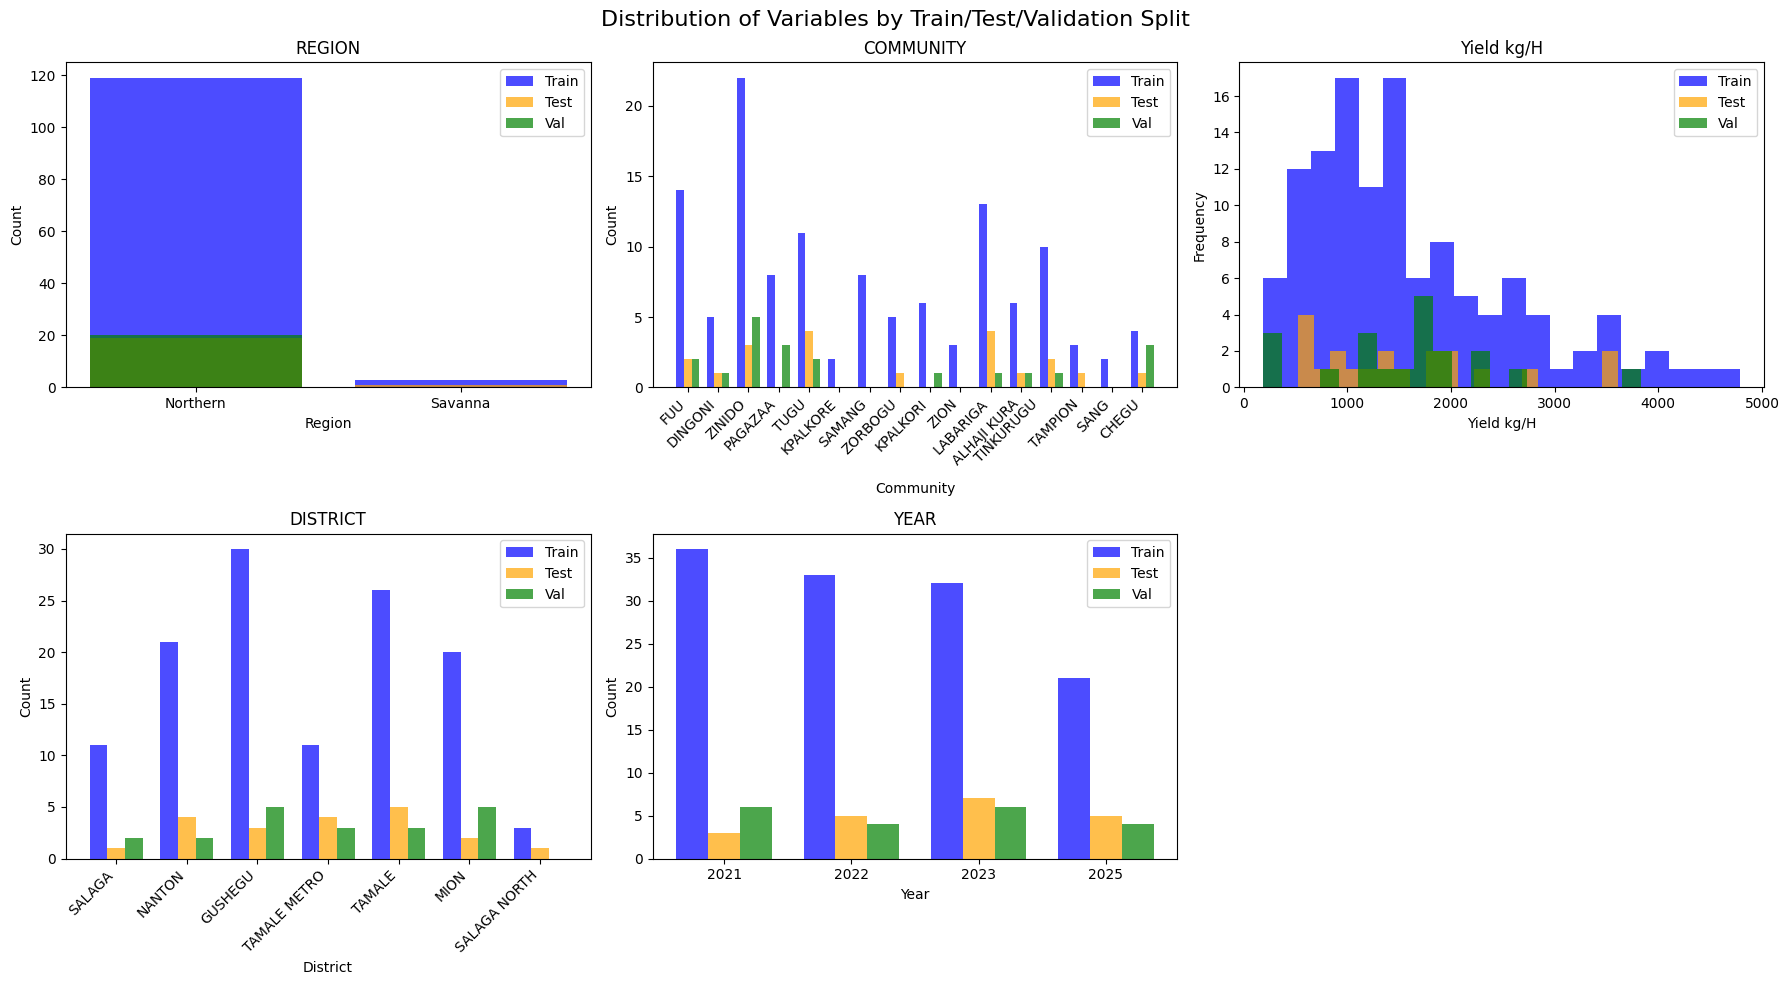

In [7]:
train_df, test_df, val_df = train_test_val_split(
    extractions,
    uniform_sample_by=unique_id_column,
    sampling_frac=0.75,
    nmin_per_class=1, # do not change this parameter
)
plot_distribution(train_df, test_df, val_df, target_column)

#### Original Data

##### Random Forest

In [8]:
s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [9]:
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

In [10]:
import numpy as np 

X_train = X_train.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

R2_score on Train: 0.8661576027943925
R2_score on Val: -0.567253498932508
R2_score on Test: -0.2835883402620838


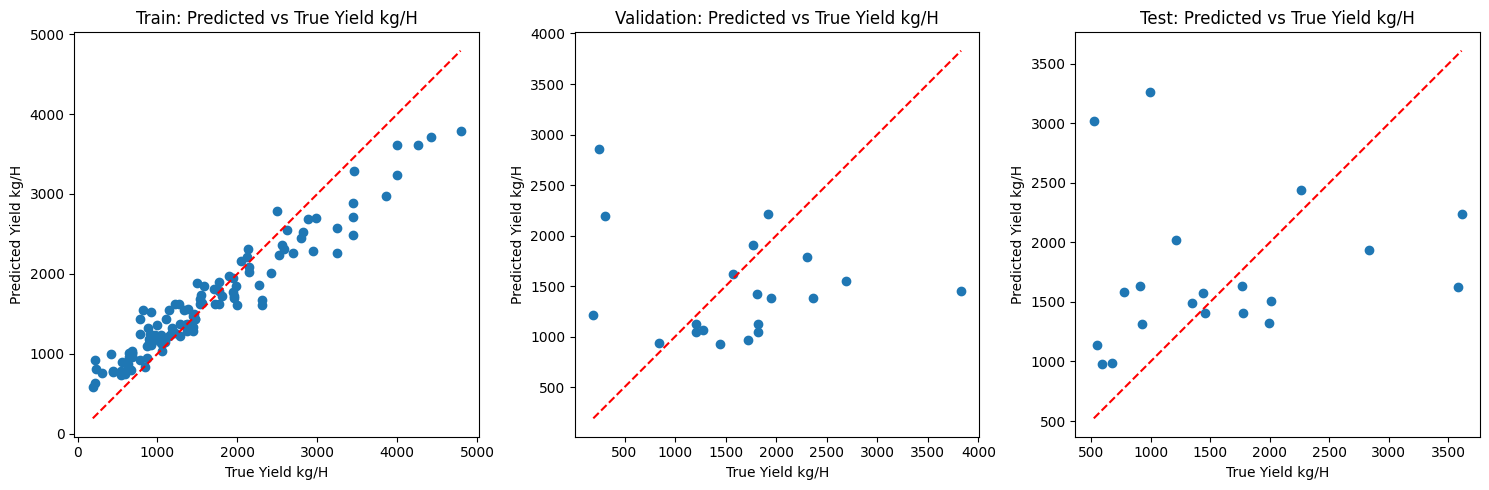

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ))
])

rf_pipe.fit(X_train, y_train)
print("R2_score on Train:", rf_pipe.score(X_train, y_train))
print("R2_score on Val:", rf_pipe.score(X_val, y_val))
print("R2_score on Test:", rf_pipe.score(X_test, y_test))

preds_train = rf_pipe.predict(X_train)
preds_val = rf_pipe.predict(X_val)
preds_test = rf_pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Catboost 

0:	learn: 992.7208671	total: 54ms	remaining: 26.9s
499:	learn: 376.9466645	total: 1.17s	remaining: 0us
R2_score on Train: 0.8565882047171307
R2_score on Val: -0.3183386301159363
R2_score on Test: -0.15858265277480577


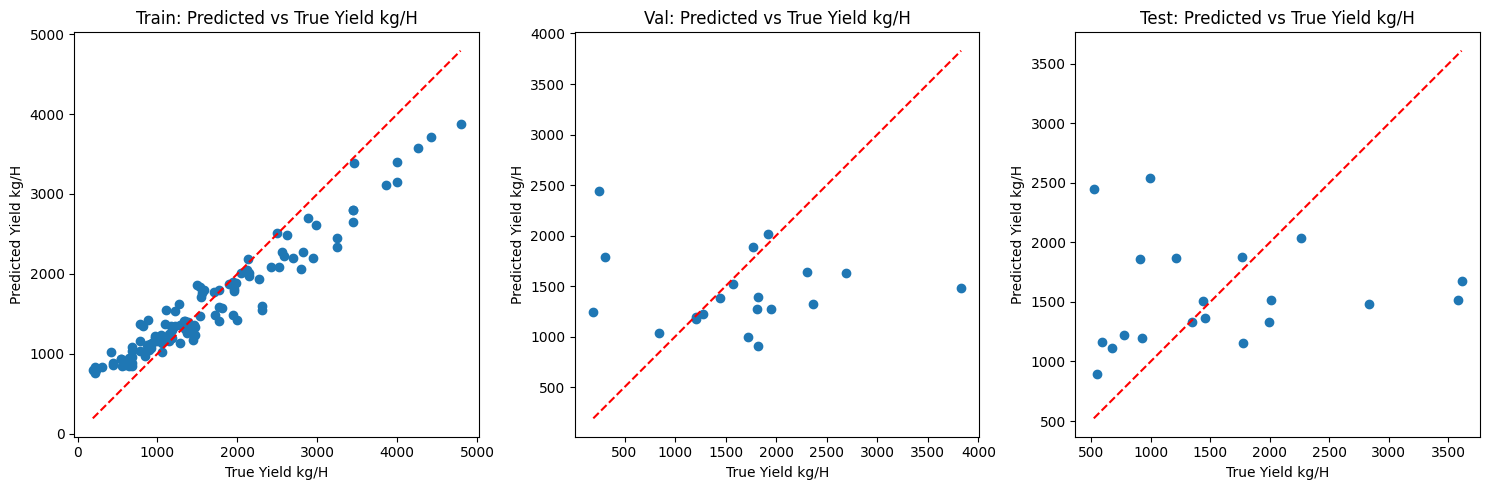

In [12]:
from catboost import CatBoostRegressor
cat_reg = CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose = 500
)

cat_reg.fit(X_train, y_train,
)

print("R2_score on Train:", cat_reg.score(X_train, y_train))
print("R2_score on Val:", cat_reg.score(X_val, y_val))
print("R2_score on Test:", cat_reg.score(X_test, y_test))

preds_train = cat_reg.predict(X_train) 
preds_val = cat_reg.predict(X_val)
preds_test = cat_reg.predict(X_test)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Val: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")

plt.tight_layout()
plt.show()

##### Presto

In [13]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "regression"
target_name="Yield kg/H"
target_mean = train_df[target_name].mean()
target_std = train_df[target_name].std()   

In [14]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

In [15]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("/home/giorgia/Private/data/geomaize/models/")
experiment_name = f"presto-scaleag-ft-{composite_window}-geomaize"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32  # Back to original batch size
num_workers = 0
max_epochs = 200  # Keep reasonable number of epochs
patience = 30  # More patience for convergence
freeze_layers = ['encoder']
unfreeze_epoch = 200  # Keep early unfreezing

In [16]:
loss_fn = nn.MSELoss()
# pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except Exception:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
        pretrained_model_path=pretrained_model_path,
    )

end_lr = 1e-5
start_lr = 1e-3
drop_factor = end_lr / start_lr
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=start_lr)
for group in optimizer.param_groups:
    group["initial_lr"] = start_lr

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=start_lr,
)

scheduler_head = lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=unfreeze_epoch)
scheduler_warmup = lr_scheduler.LinearLR(optimizer, start_factor=0.1 * drop_factor, end_factor=drop_factor, total_iters=3)
scheduler_final = lr_scheduler.LambdaLR(
                                optimizer,
                                lr_lambda=lambda step: drop_factor * (0.99**step),
                                )
scheduler = lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler_head, scheduler_warmup, scheduler_final],
    milestones=[unfreeze_epoch, unfreeze_epoch+3],
)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
    freeze_layers=freeze_layers,
    unfreeze_epoch=unfreeze_epoch,
)

2026-02-10 15:42:20.011 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/data/geomaize/models/presto-scaleag-ft-month-geomaize
2026-02-10 15:42:20.016 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.pos_embed
2026-02-10 15:42:20.017 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.weight
2026-02-10 15:42:20.017 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.bias
2026-02-10 15:42:20.018 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.weight
2026-02-10 15:42:20.018 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.bias
2026-02-10 15:42:20.019 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_Red_Edge.weight
2026-02-10 15:42:20.019 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_p

Finetuning:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-10 15:42:20.441 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/200: Epoch 1/200 | Train Loss: 2.4846 | Val Loss: 1.9428 | Best Loss: 1.9428 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-02-10 15:43:03.206 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 198/200: Epoch 198/200 | Train Loss: 0.9457 | Val Loss: 0.6727 | Best Loss: 0.6727 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-10 15:43:03.399 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 199/200: Epoch 199/200 | Train Loss: 0.9404 | Val Loss: 0.6726 | Best Loss: 0.6726 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

/home/giorgia/.conda/envs/agri/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:156: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
2026-02-10 15:43:03.580 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 200/200: Epoch 200/200 | Train Loss: 0.9379 | Val Loss: 0.6725 | Best Loss: 0.6725 (improved)
2026-02-10 15:43:03.654 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


2026-02-10 15:43:03.746 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task
2026-02-10 15:43:03.789 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task
2026-02-10 15:43:03.931 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task


{'MAPE': 0.6715, 'MSE': 795966.6875, 'R2_score': 0.0418, 'RMSE': 892.1697}
{'MAPE': 0.8426, 'MSE': 949216.125, 'R2_score': 0.0419, 'RMSE': 974.2772}
{'MAPE': 1.1081, 'MSE': 671758.8125, 'R2_score': 0.0513, 'RMSE': 819.6089}


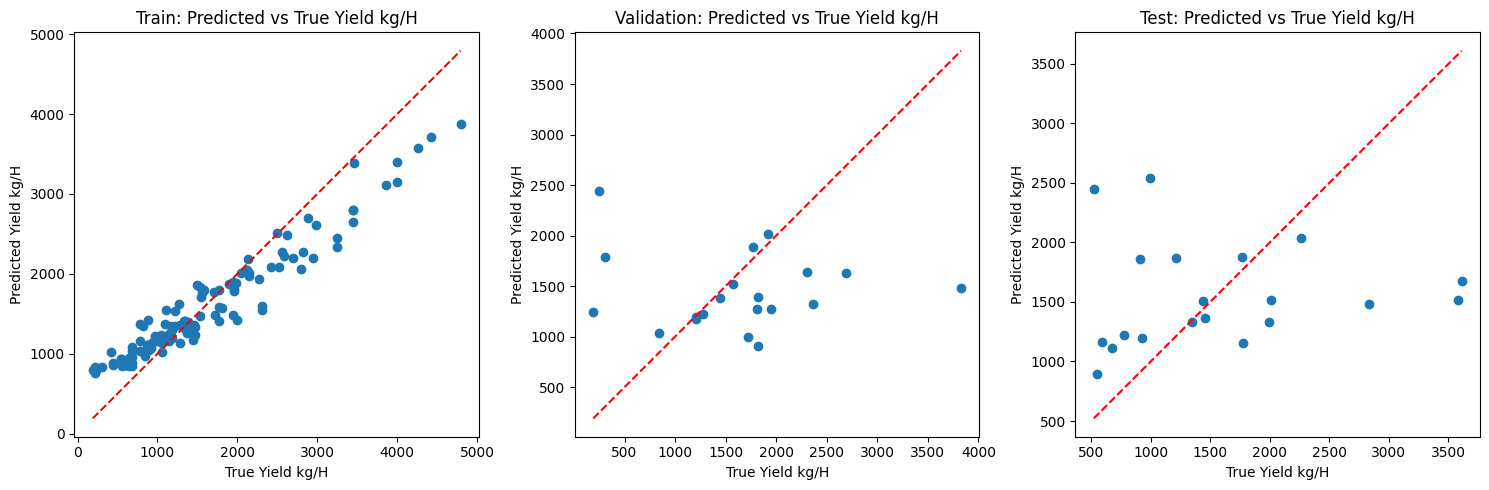

In [17]:
metrics, preds, targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

# Get predictions for train and validation sets as well
train_metrics, train_preds, train_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds, val_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Presto + Catboost 

0:	learn: 0.9937459	total: 12.6ms	remaining: 6.29s
499:	learn: 0.4636183	total: 1.85s	remaining: 0us
R2_score on Train: 0.7832816475145847
R2_score on Val: -0.5866377388009014
R2_score on Test: -0.05014464857046552


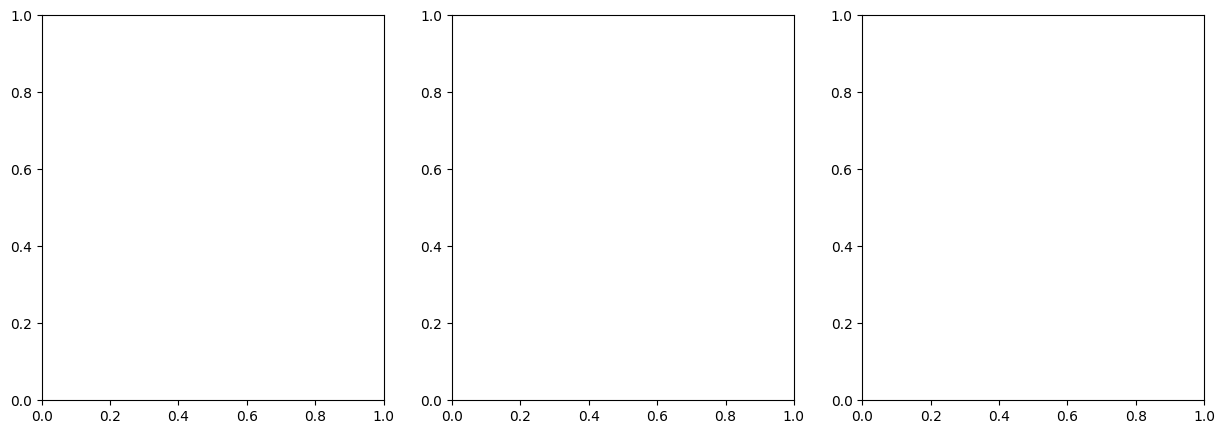

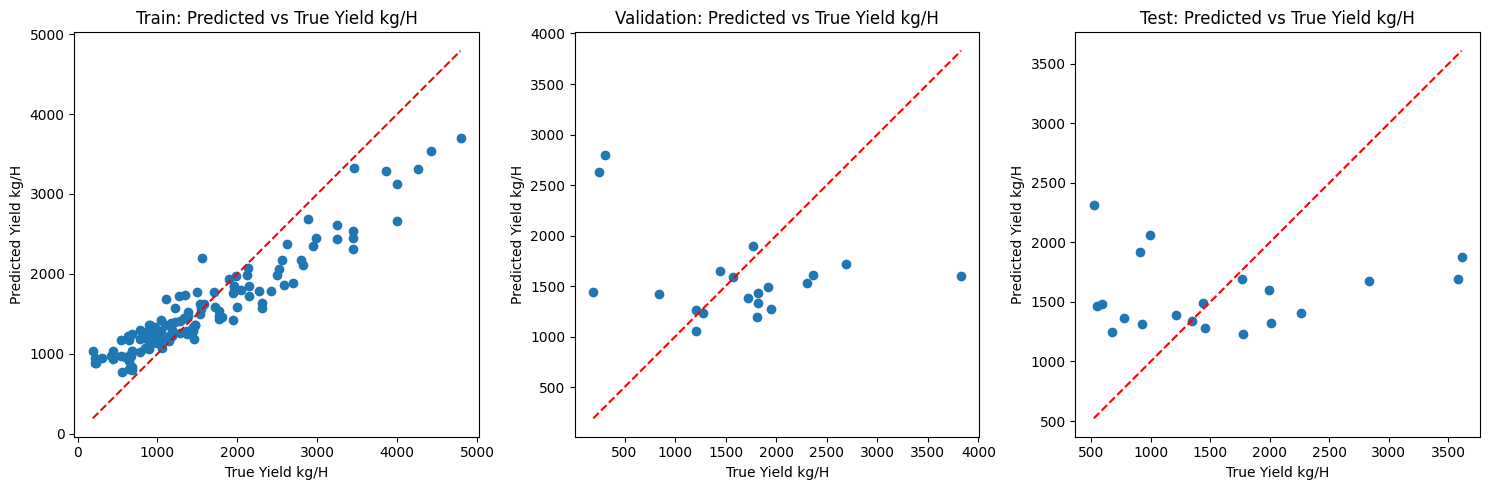

In [18]:
from scaleagdata_vito.presto.utils import get_encodings
model = PretrainedPrestoWrapper(
    num_outputs=num_outputs,
    regression=True,
)
model = load_presto_weights(model, pretrained_model_path, strict=False)

from torch.utils.data import DataLoader

all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("cat", CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose=500
    ))
])

cat_enc_pipe.fit(all_encodings, all_targets)
print("R2_score on Train:", cat_enc_pipe.score(all_encodings, all_targets))
print("R2_score on Val:", cat_enc_pipe.score(all_encodings_val, all_targets_val))
print("R2_score on Test:", cat_enc_pipe.score(all_encodings_test, all_targets_test))

preds_train = cat_enc_pipe.predict(all_encodings)
preds_val = cat_enc_pipe.predict(all_encodings_val)
preds_test = cat_enc_pipe.predict(all_encodings_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

preds_train = train_ds.revert_to_original_units(preds_train)
preds_val = val_ds.revert_to_original_units(preds_val)
preds_test = test_ds.revert_to_original_units(preds_test)
all_targets = train_ds.revert_to_original_units(all_targets)
all_targets_val = val_ds.revert_to_original_units(all_targets_val)
all_targets_test = test_ds.revert_to_original_units(all_targets_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(all_targets, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

#### Augmented data

In [19]:
# strategy to get month array
import numpy as np 

def add_band_noise(df: pd.DataFrame, cols, sigma, per_row_bias=0.0, clip=None, rng=None):
    """
    Add Gaussian noise to selected columns.
    - sigma: float, or dict[col]->sigma
    - per_row_bias: add a constant bias per row (Gaussian with std=per_row_bias) across these cols
    - clip: tuple(min,max) or None
    """

    rng = np.random.default_rng() if rng is None else rng
    out = df.copy()

    X = out[cols].to_numpy(dtype=float)
    noise = rng.normal(0.0, 1.0, size=X.shape)

    if isinstance(sigma, dict):
        sig = np.array([sigma.get(c, 0.0) for c in cols], dtype=float)[None, :]
        Xn = X + noise * sig
    else:
        Xn = X + noise * float(sigma)

    if per_row_bias and per_row_bias > 0:
        bias = rng.normal(0.0, per_row_bias, size=(X.shape[0], 1))
        Xn = Xn + bias

    # preserve NaNs: adding noise would keep NaNs as NaN in numpy, but be explicit
    Xn[np.isnan(X)] = np.nan

    if clip is not None:
        Xn = np.clip(Xn, clip[0], clip[1])

    out[cols] = Xn
    return out

s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]

noise_variants = 4
train_nans = train_df.replace(65535, np.nan)
X_parts = [train_nans]
for k in range(noise_variants):
    Xk = train_nans.copy()
    rng = np.random.default_rng(42 + k)  # Different seed for each variant
    if s2_cols:
        Xk = add_band_noise(Xk, s2_cols, sigma=0.015, clip=(0.0, train_df[s2_cols].max().max()), rng=rng)
    if s1_cols:
        Xk = add_band_noise(Xk, s1_cols, sigma=0.4, per_row_bias=0.2, rng=rng)
    if meteo_cols:
        # conservative generic noise (you can refine per-variable by passing a sigma dict)
        Xk = add_band_noise(Xk, meteo_cols, sigma=0.02 * np.nanstd(train_nans[meteo_cols].to_numpy(dtype=float), axis=0, keepdims=True).mean(),
                        rng=rng)
    Xk['sample_id'] = Xk['sample_id'] + f"_AUG{k}"
    X_parts.append(Xk)

train_df_augmented = pd.concat(X_parts, ignore_index=True)
train_df_augmented.replace(np.nan, 65535, inplace=True)

print(f"Original train size: {len(train_df)}, Augmented train size: {len(train_df_augmented)}")
    

Original train size: 122, Augmented train size: 610


##### Random Forest

In [20]:
X_train_augmented, y_train_augmented = train_df_augmented[feature_columns], train_df_augmented[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [21]:
import numpy as np 

X_train_augmented = X_train_augmented.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

R2_score on Train: 0.9959419694917264
R2_score on Val: -0.6926718055342587
R2_score on Test: -0.533585876527515


ValueError: x and y must be the same size

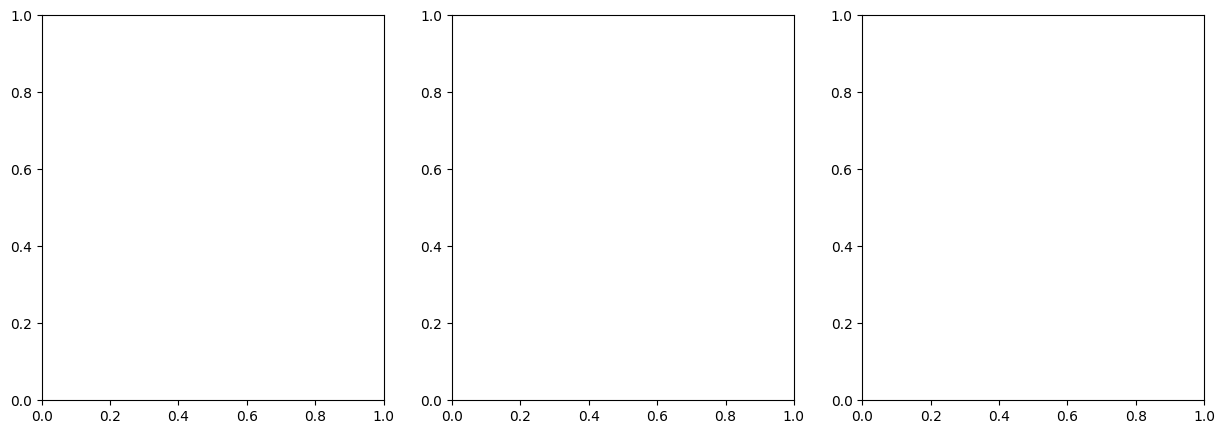

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ))
])

rf_pipe.fit(X_train_augmented, y_train_augmented)
print("R2_score on Train:", rf_pipe.score(X_train_augmented, y_train_augmented))
print("R2_score on Val:", rf_pipe.score(X_val, y_val))
print("R2_score on Test:", rf_pipe.score(X_test, y_test))

preds_train = rf_pipe.predict(X_train_augmented)
preds_val = rf_pipe.predict(X_val)
preds_test = rf_pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Catboost 

0:	learn: 1026.6752169	total: 15.2ms	remaining: 7.6s
1:	learn: 1022.5039744	total: 29ms	remaining: 7.22s
2:	learn: 1018.0873497	total: 36.7ms	remaining: 6.08s
3:	learn: 1013.7663619	total: 44.5ms	remaining: 5.52s
4:	learn: 1008.7020700	total: 51.9ms	remaining: 5.14s
5:	learn: 1003.8565186	total: 56.4ms	remaining: 4.65s
6:	learn: 999.3559796	total: 60.8ms	remaining: 4.28s
7:	learn: 995.1659619	total: 66.6ms	remaining: 4.1s
8:	learn: 990.7041858	total: 70.7ms	remaining: 3.86s
9:	learn: 986.5691012	total: 74.7ms	remaining: 3.66s
10:	learn: 981.6276130	total: 78.9ms	remaining: 3.51s
11:	learn: 977.6948050	total: 83ms	remaining: 3.38s
12:	learn: 974.0794685	total: 89.1ms	remaining: 3.34s
13:	learn: 970.2299969	total: 93ms	remaining: 3.23s
14:	learn: 966.7881366	total: 97.5ms	remaining: 3.15s
15:	learn: 962.4559344	total: 102ms	remaining: 3.08s
16:	learn: 958.5661620	total: 106ms	remaining: 3s
17:	learn: 954.8335056	total: 110ms	remaining: 2.95s
18:	learn: 950.1397384	total: 114ms	remaining:

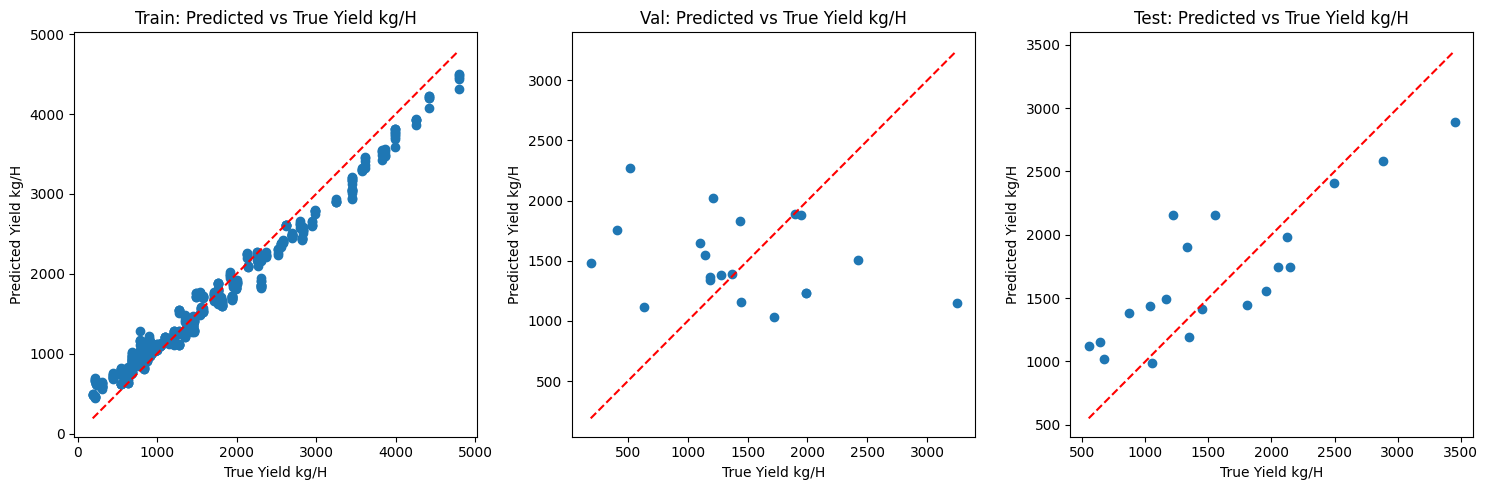

In [ ]:
from catboost import CatBoostRegressor
cat_reg = CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose=500
)


cat_reg.fit(X_train_augmented, y_train_augmented)

print("R2_score on Train:", cat_reg.score(X_train_augmented, y_train_augmented))
print("R2_score on Val:", cat_reg.score(X_val, y_val))
print("R2_score on Test:", cat_reg.score(X_test, y_test))

preds_train = cat_reg.predict(X_train_augmented) 
preds_val = cat_reg.predict(X_val)
preds_test = cat_reg.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Presto

In [ ]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "regression"
target_name="Yield kg/H"
target_mean = train_df[target_name].mean()
target_std = train_df[target_name].std()   

In [ ]:
train_ds = ScaleAgDataset(
    dataframe=train_df_augmented,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

In [ ]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("/home/giorgia/Private/data/geomaize/models/")
experiment_name = f"presto-scaleag-ft-{composite_window}-geomaize-aug"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32  # Back to original batch size
num_workers = 0
max_epochs = 200  # Keep reasonable number of epochs
patience = 30  # More patience for convergence
freeze_layers = ['encoder']
unfreeze_epoch = 200  # Keep early unfreezing

In [ ]:
loss_fn = nn.MSELoss()
# pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except Exception:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
        pretrained_model_path=pretrained_model_path,
    )

end_lr = 1e-5
start_lr = 1e-3
drop_factor = end_lr / start_lr
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=start_lr)
for group in optimizer.param_groups:
    group["initial_lr"] = start_lr

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=start_lr,
)

scheduler_head = lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=unfreeze_epoch)
scheduler_warmup = lr_scheduler.LinearLR(optimizer, start_factor=0.1 * drop_factor, end_factor=drop_factor, total_iters=3)
scheduler_final = lr_scheduler.LambdaLR(
                                optimizer,
                                lr_lambda=lambda step: drop_factor * (0.99**step),
                                )
scheduler = lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler_head, scheduler_warmup, scheduler_final],
    milestones=[unfreeze_epoch, unfreeze_epoch+3],
)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
    freeze_layers=freeze_layers,
    unfreeze_epoch=unfreeze_epoch,
)

2026-02-10 15:18:01.527 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/data/geomaize/models/presto-scaleag-ft-month-geomaize-aug
2026-02-10 15:18:01.529 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.pos_embed
2026-02-10 15:18:01.529 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.weight
2026-02-10 15:18:01.530 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.bias
2026-02-10 15:18:01.530 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.weight
2026-02-10 15:18:01.530 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.bias
2026-02-10 15:18:01.531 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_Red_Edge.weight
2026-02-10 15:18:01.531 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.

Finetuning:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

2026-02-10 15:18:02.111 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/200: Epoch 1/200 | Train Loss: 1.6313 | Val Loss: 0.5948 | Best Loss: 0.5948 (improved)


Training:   0%|          | 0/20 [00:00<?, ?it/s]

...

2026-02-10 15:18:40.726 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 59/200: Epoch 59/200 | Train Loss: 0.9377 | Val Loss: 0.5145 | Best Loss: 0.4932 (no improvement for 28 epochs)


Training:   0%|          | 0/20 [00:00<?, ?it/s]

2026-02-10 15:18:41.423 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 60/200: Epoch 60/200 | Train Loss: 0.8952 | Val Loss: 0.5288 | Best Loss: 0.4932 (no improvement for 29 epochs)


Training:   0%|          | 0/20 [00:00<?, ?it/s]

2026-02-10 15:18:42.419 | INFO     | prometheo.finetune:_train_loop:161 - Early stopping!
2026-02-10 15:18:42.471 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


2026-02-10 15:18:42.550 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task
2026-02-10 15:18:42.588 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task


{'MAPE': 0.4742, 'MSE': 573711.125, 'R2_score': -0.0108, 'RMSE': 757.4372}


2026-02-10 15:18:43.304 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task


{'MAPE': 0.8604, 'MSE': 1056282.875, 'R2_score': 0.0067, 'RMSE': 1027.7562}
{'MAPE': 0.8578, 'MSE': 528847.375, 'R2_score': -0.0708, 'RMSE': 727.2189}


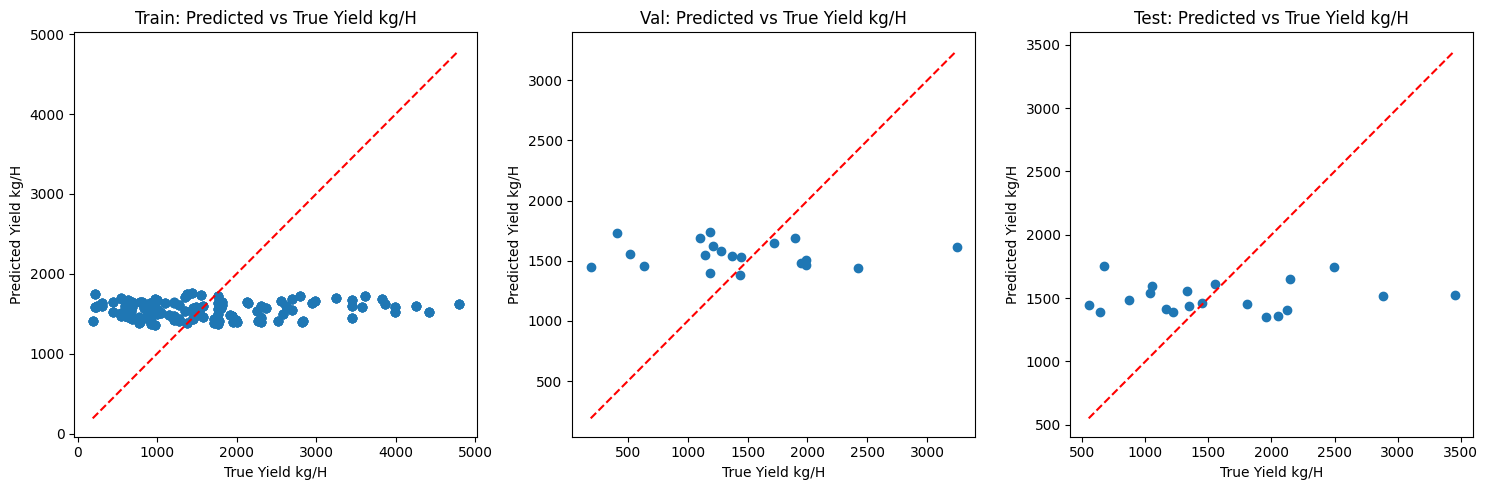

In [ ]:
metrics, preds, targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

# Get predictions for train and validation sets as well
train_metrics, train_preds, train_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds, val_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Presto + Catboost 

0:	learn: 0.9953598	total: 17.1ms	remaining: 1m 25s
100:	learn: 0.9560482	total: 703ms	remaining: 34.1s
200:	learn: 0.9196073	total: 1.33s	remaining: 31.7s
300:	learn: 0.8844195	total: 2.07s	remaining: 32.3s
400:	learn: 0.8520760	total: 2.68s	remaining: 30.8s
500:	learn: 0.8213370	total: 3.29s	remaining: 29.5s
600:	learn: 0.7929664	total: 3.96s	remaining: 29s
700:	learn: 0.7662847	total: 4.61s	remaining: 28.3s
800:	learn: 0.7406114	total: 5.22s	remaining: 27.4s
900:	learn: 0.7174120	total: 5.83s	remaining: 26.5s
1000:	learn: 0.6956439	total: 6.51s	remaining: 26s
1100:	learn: 0.6746840	total: 7.1s	remaining: 25.2s
1200:	learn: 0.6544447	total: 7.67s	remaining: 24.3s
1300:	learn: 0.6355634	total: 8.2s	remaining: 23.3s
1400:	learn: 0.6178252	total: 8.88s	remaining: 22.8s
1500:	learn: 0.6006858	total: 9.47s	remaining: 22.1s
1600:	learn: 0.5846378	total: 10.1s	remaining: 21.4s
1700:	learn: 0.5689746	total: 10.8s	remaining: 21s
1800:	learn: 0.5537692	total: 11.4s	remaining: 20.3s
1900:	learn

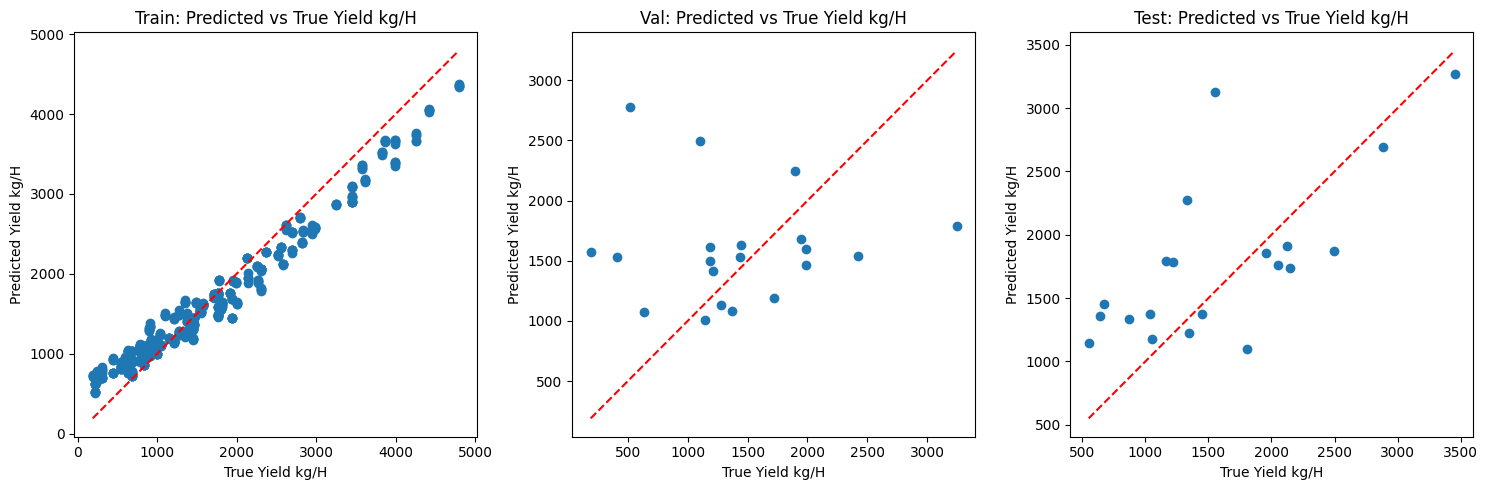

In [ ]:
from scaleagdata_vito.presto.utils import get_encodings
model = PretrainedPrestoWrapper(
    num_outputs=num_outputs,
    regression=True,
)
model = load_presto_weights(model, pretrained_model_path, strict=False)

from torch.utils.data import DataLoader

all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("cat", CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose=500
    ))
])

cat_enc_pipe.fit(all_encodings, all_targets)
print("R2_score on Train:", cat_enc_pipe.score(all_encodings, all_targets))
print("R2_score on Val:", cat_enc_pipe.score(all_encodings_val, all_targets_val))
print("R2_score on Test:", cat_enc_pipe.score(all_encodings_test, all_targets_test))

preds_train = cat_enc_pipe.predict(all_encodings)
preds_val = cat_enc_pipe.predict(all_encodings_val)
preds_test = cat_enc_pipe.predict(all_encodings_test)

preds_train = train_ds.revert_to_original_units(preds_train)
preds_val = val_ds.revert_to_original_units(preds_val)
preds_test = test_ds.revert_to_original_units(preds_test)
all_targets = train_ds.revert_to_original_units(all_targets)
all_targets_val = val_ds.revert_to_original_units(all_targets_val)
all_targets_test = test_ds.revert_to_original_units(all_targets_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(all_targets, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()